In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 모든 컬럼 보이게 설정 (None은 제한 없음을 의미)
pd.set_option('display.max_columns', None)

# 다시 원래대로(생략 모드) 되돌리고 싶을 때
# pd.reset_option('display.max_columns')

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [5]:
# 1. 데이터 로드 (FD001 세트 사용)
train_url = 'train_FD001.txt'
columns = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]
train_df = pd.read_csv(train_url, sep='\s+', header=None, names=columns)
print(f"데이터 크기: {train_df.shape}")
print(f"컬럼들: {train_df.columns.to_list()}")

데이터 크기: (20631, 26)
컬럼들: ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


In [6]:
# 2. 전처리: RUL(잔존 수명) 계산
# 엔진별로 최대 사이클을 찾은 뒤, 현재 사이클을 빼서 남은 수명을 구합니다.
def add_remaining_useful_life(df):
    # 각 엔진(unit_nr)별 최대 사이클 계산
    max_cycle = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycle.columns = ['unit_nr', 'max_cycle']

    # 원본 데이터와 결합
    df = df.merge(max_cycle, on=['unit_nr'], how='left')

    # RUL = 최대 수명 - 현재 가동 시간
    df['RUL'] = df['max_cycle'] - df['time_cycles']
    df.drop('max_cycle', axis=1, inplace=True)
    return df

train_df = add_remaining_useful_life(train_df)
train_df

,unit_nr,time_cycles,os_1,os_2,os_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


In [7]:
L = []
for col in train_df.columns:
    print( f"컬럼: {col},\t 유일한 갯수: {train_df[col].nunique()}" )
    if train_df[col].nunique() <= 1:
        L.append(col)
L

컬럼: unit_nr,	 유일한 갯수: 100
컬럼: time_cycles,	 유일한 갯수: 362
컬럼: os_1,	 유일한 갯수: 158
컬럼: os_2,	 유일한 갯수: 13
컬럼: os_3,	 유일한 갯수: 1
컬럼: s_1,	 유일한 갯수: 1
컬럼: s_2,	 유일한 갯수: 310
컬럼: s_3,	 유일한 갯수: 3012
컬럼: s_4,	 유일한 갯수: 4051
컬럼: s_5,	 유일한 갯수: 1
컬럼: s_6,	 유일한 갯수: 2
컬럼: s_7,	 유일한 갯수: 513
컬럼: s_8,	 유일한 갯수: 53
컬럼: s_9,	 유일한 갯수: 6403
컬럼: s_10,	 유일한 갯수: 1
컬럼: s_11,	 유일한 갯수: 159
컬럼: s_12,	 유일한 갯수: 427
컬럼: s_13,	 유일한 갯수: 56
컬럼: s_14,	 유일한 갯수: 6078
컬럼: s_15,	 유일한 갯수: 1918
컬럼: s_16,	 유일한 갯수: 1
컬럼: s_17,	 유일한 갯수: 13
컬럼: s_18,	 유일한 갯수: 1
컬럼: s_19,	 유일한 갯수: 1
컬럼: s_20,	 유일한 갯수: 120
컬럼: s_21,	 유일한 갯수: 4745
컬럼: RUL,	 유일한 갯수: 362


['os_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']

In [8]:
# 3. 데이터 정제: 변화가 없는(분산=0) 센서 제거
# 값이 변하지 않는 센서는 예측에 도움이 되지 않습니다.
const_columns = [col for col in train_df.columns if train_df[col].nunique() <= 1]
print(f"제거된 불필요 센서: {const_columns}")
train_df.drop(columns=const_columns, inplace=True)
train_df

제거된 불필요 센서: ['os_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']


,unit_nr,time_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,3
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1


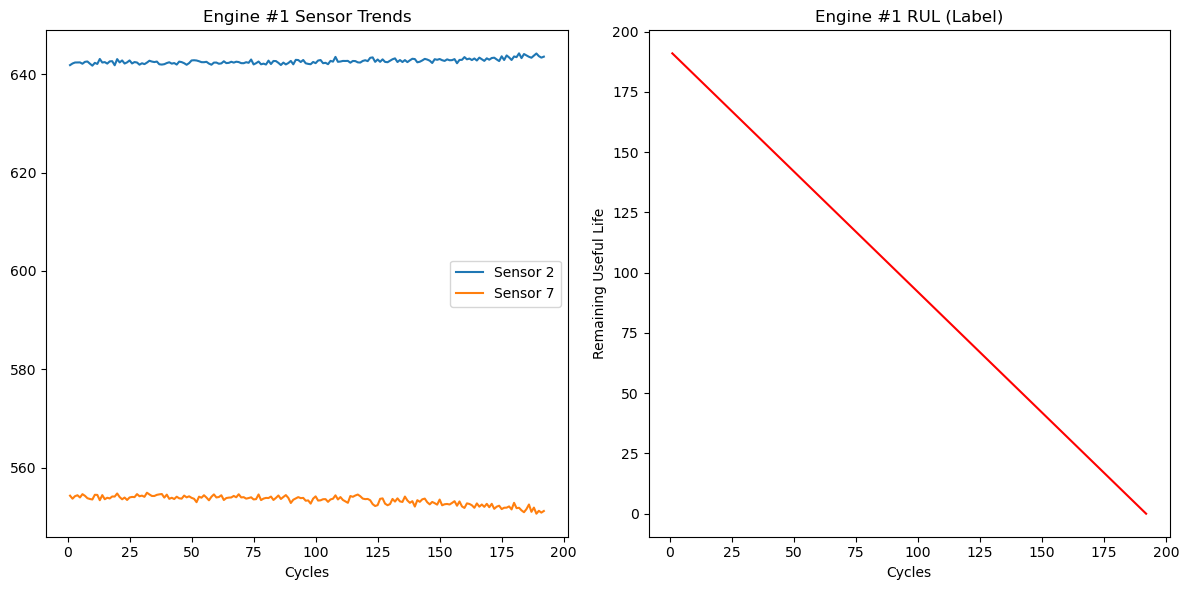

In [9]:
# 4. 시각화 (EDA)
# 특정 엔진(예: 1번 엔진)의 시간에 따른 센서 데이터 및 RUL 변화

def plot_sensor_trends(df, unit_nr=1):
    plt.figure(figsize=(12, 6))
    unit_data = df[df['unit_nr'] == unit_nr]

    plt.subplot(1, 2, 1)
    plt.plot(unit_data['time_cycles'], unit_data['s_2'], label='Sensor 2')
    plt.plot(unit_data['time_cycles'], unit_data['s_7'], label='Sensor 7')
    plt.title(f'Engine #{unit_nr} Sensor Trends')
    plt.xlabel('Cycles')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(unit_data['time_cycles'], unit_data['RUL'], color='red')
    plt.title(f'Engine #{unit_nr} RUL (Label)')
    plt.xlabel('Cycles')
    plt.ylabel('Remaining Useful Life')
    plt.tight_layout()
    plt.show()

plot_sensor_trends(train_df)

In [10]:
# 5. 특성 공학 (Feature Engineering)
# 이동 평균(Rolling Mean)을 추가하여 노이즈를 줄이고 추세를 강조합니다.
sensor_cols = [col for col in train_df.columns if col.startswith('s_')]
train_df[sensor_cols] = train_df.groupby('unit_nr')[sensor_cols].rolling(window=5).mean().reset_index(0, drop=True)
train_df.dropna(inplace=True) # 이동평균으로 인한 초기 결측치 제거
train_df

,unit_nr,time_cycles,os_1,os_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
4,1,5,-0.0019,-0.0002,642.208,1587.030,1403.206,21.61,554.164,2388.070,9049.566,47.328,522.282,2388.048,8134.194,8.41334,391.8,38.958,23.39302,187
5,1,6,-0.0043,-0.0001,642.264,1585.984,1402.760,21.61,554.226,2388.062,9050.264,47.266,522.286,2388.050,8133.040,8.41160,391.6,38.942,23.38260,186
6,1,7,0.0010,0.0001,642.330,1586.084,1401.686,21.61,554.344,2388.058,9053.276,47.240,522.294,2388.042,8133.206,8.40472,391.6,38.962,23.37336,185
7,1,8,-0.0034,0.0003,642.372,1585.078,1401.040,21.61,554.262,2388.042,9050.848,47.234,522.304,2388.042,8132.774,8.40268,391.8,38.966,23.36664,184
8,1,9,0.0008,0.0001,642.326,1586.716,1399.626,21.61,554.110,2388.030,9050.244,47.266,522.090,2388.036,8131.146,8.40360,391.8,39.000,23.37318,183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.448,1599.270,1427.270,21.61,551.604,2388.222,9066.416,48.156,519.890,2388.232,8141.130,8.52012,395.8,38.408,23.07964,4
20627,100,197,-0.0016,-0.0005,643.450,1599.924,1430.090,21.61,551.548,2388.234,9067.348,48.128,519.708,2388.234,8139.738,8.52506,395.4,38.356,23.09612,3
20628,100,198,0.0004,0.0000,643.516,1600.454,1429.940,21.61,551.328,2388.224,9067.014,48.108,519.688,2388.244,8139.544,8.52950,395.6,38.350,23.07818,2
20629,100,199,-0.0011,0.0003,643.418,1602.048,1429.764,21.61,551.066,2388.228,9067.988,48.162,519.712,2388.246,8139.468,8.53298,395.8,38.332,23.06450,1


In [11]:
# 6. 학습 준비
# unit_nr (엔진 ID): "이름을 외우지 말고 특징을 배워라"
# time_cycles (가동 시간): "커닝(Cheating) 방지" : RUL(잔존 수명)은 애초에 최대 수명 - 현재 가동 시간으로 계산
X = train_df.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y = train_df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print( X.columns.to_list() )

['os_1', 'os_2', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [13]:
# 7. 머신러닝 모델링
# Random Forest (배깅) vs XGBoost (부스팅) 비교
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"[{name}] RMSE: {rmse:.2f}, R2: {r2:.2f}")
# 8.47s

[RandomForest] RMSE: 33.18, R2: 0.76
[XGBoost] RMSE: 35.57, R2: 0.73


In [14]:
# 8. 하이퍼파라미터 튜닝 (RandomizedSearch)
# 실무에서 가장 많이 쓰이는 효율적인 튜닝 방식입니다.
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_tuned = RandomizedSearchCV(XGBRegressor(), param_distributions=param_dist, n_iter=5, cv=3, random_state=42)
xgb_tuned.fit(X_train, y_train)

print(f"최적 파라미터: {xgb_tuned.best_params_}")
# 5.25s

최적 파라미터: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.01}


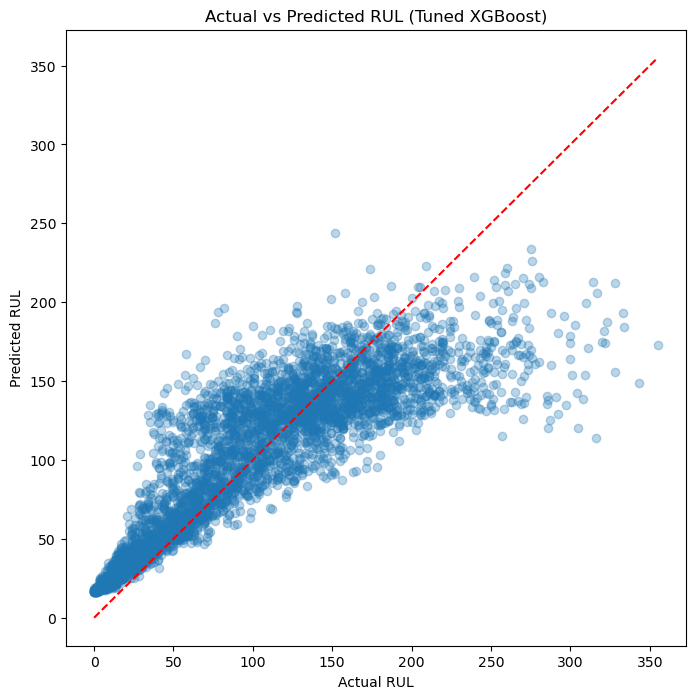

In [15]:
# 9. 결과 시각화: 실제값 vs 예측값
final_preds = xgb_tuned.predict(X_test)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, final_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Actual vs Predicted RUL (Tuned XGBoost)')
plt.show()

In [16]:
# end